# Image to Text / Vision AI Demo

## Secure API Key Setup

This notebook is safe to upload to GitHub because the API key is **not stored in the notebook**.

Before running it in Google Colab:

1. Open the **Secrets** panel in Colab (key icon on the left sidebar).
2. Create a secret named `NAVIGATE_API_KEY`.
3. Paste your API key as the secret value.
4. Enable notebook access for that secret.

Never paste the actual API key directly into a code cell or commit it to GitHub.


In [10]:
!pip install -q openai pillow

In [11]:
from google.colab import userdata, files
from PIL import Image
from IPython.display import display
import base64
import openai


In [12]:
# -----------------------------
# Secure API Configuration
# -----------------------------
# The key is stored in Google Colab Secrets, not in this notebook.
api_key = userdata.get("NAVIGATE_API_KEY")

if not api_key:
    raise ValueError(
        "API key not found. Add NAVIGATE_API_KEY in Google Colab Secrets "
        "and enable notebook access."
    )

client = openai.OpenAI(
    api_key=api_key,
    base_url="https://nexusapi.navigatelabs.ai"
)

print("API client configured securely.")


API client configured securely.


Saving FOODLENS AI.png to FOODLENS AI (3).png


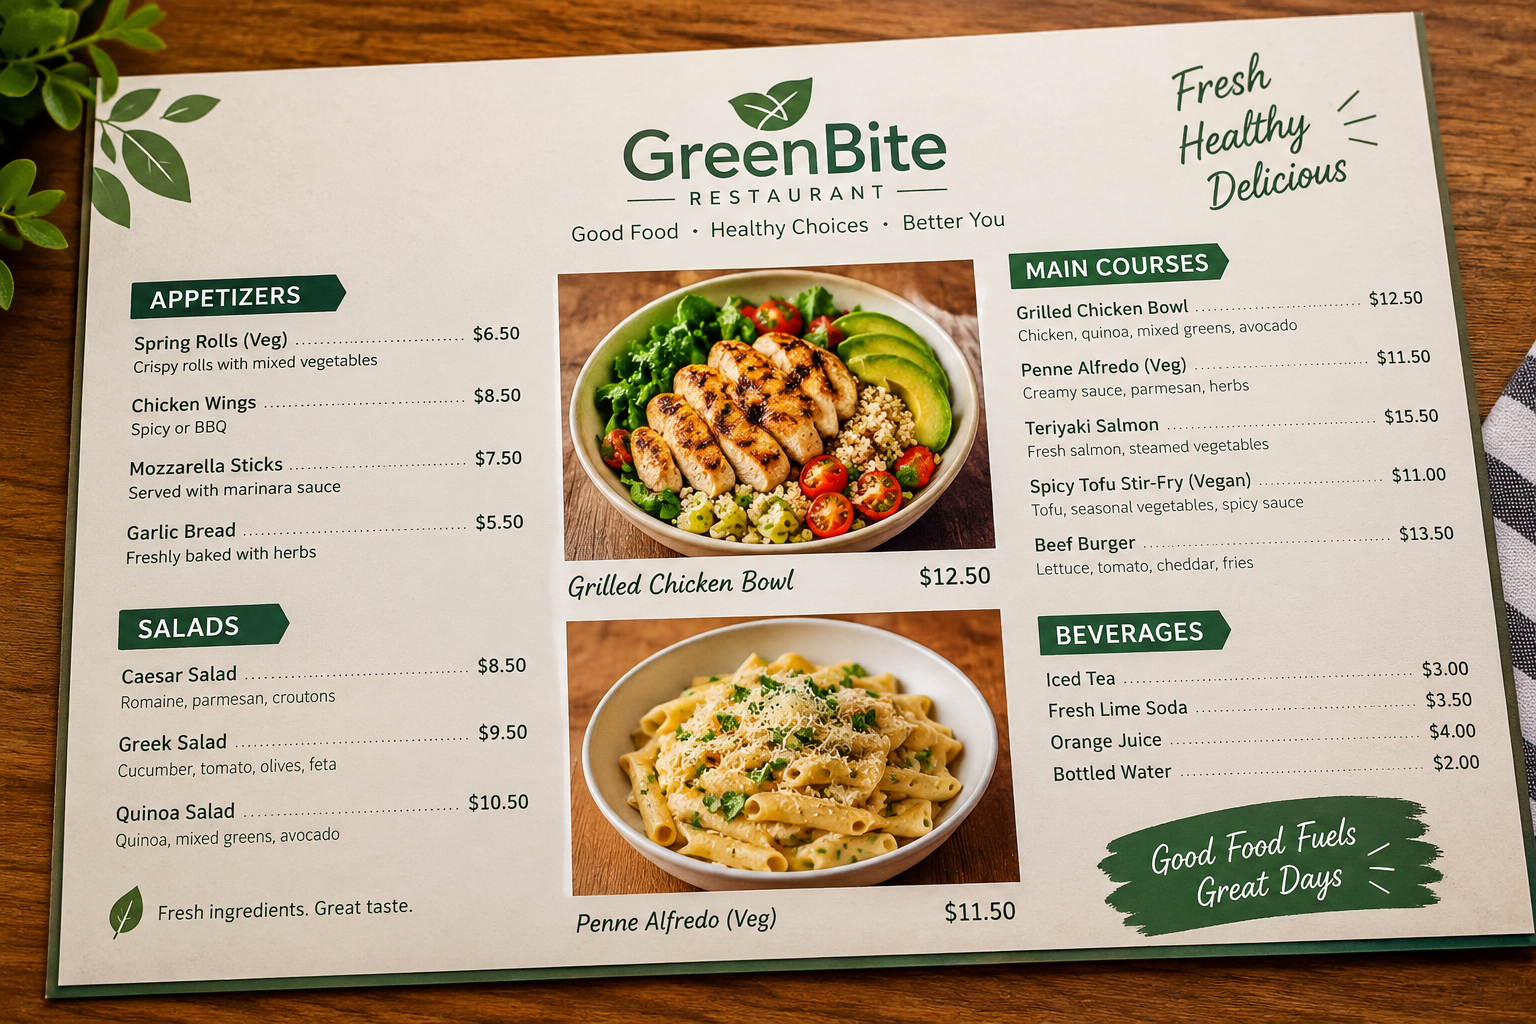

In [13]:
# -----------------------------
# Upload Image
# -----------------------------
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

# Display the uploaded image
img = Image.open(image_path)
display(img)

In [14]:
# -----------------------------
# Ask user for a question
# -----------------------------
question = input("Ask a question about the uploaded image: ").strip()

if not question:
    raise ValueError("Question cannot be empty.")

# -----------------------------
# Convert image to Base64
# -----------------------------
with open(image_path, "rb") as f:
    image_base64 = base64.b64encode(f.read()).decode("utf-8")

# Detect the image MIME type from the uploaded image.
image_format = (img.format or "JPEG").lower()
if image_format == "jpg":
    image_format = "jpeg"
mime_type = f"image/{image_format}"


Ask a question about the uploaded image: DESCRIBE THE IMAGE


In [15]:
# -----------------------------
# Send Image + Text to Model
# -----------------------------
response = client.chat.completions.create(
    model="gemini-2.5-flash",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": question
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:{mime_type};base64,{image_base64}"
                    }
                }
            ]
        }
    ]
)

print("\nModel Response:\n")
print(response.choices[0].message.content)


PermissionDeniedError: Error code: 403 - {'error': {'message': 'litellm.BadRequestError: GeminiException BadRequestError - {\n  "error": {\n    "code": 403,\n    "message": "Permission denied: Consumer \'REDACTED\' has been suspended.",\n    "status": "PERMISSION_DENIED",\n    "details": [\n      {\n        "@type": "type.googleapis.com/google.rpc.ErrorInfo",\n        "reason": "CONSUMER_SUSPENDED",\n        "domain": "googleapis.com",\n        "metadata": {\n          "containerInfo": "REDACTED",\n          "consumer": "projects/65157353051",\n          "service": "generativelanguage.googleapis.com"\n        }\n      },\n      {\n        "@type": "type.googleapis.com/google.rpc.LocalizedMessage",\n        "locale": "en-US",\n        "message": "Permission denied: Consumer \'REDACTED\' has been suspended."\n      }\n    ]\n  }\n}\n. Received Model Group=gemini-2.5-flash\nAvailable Model Group Fallbacks=None', 'type': None, 'param': None, 'code': '403'}}

## Alternative: Accessing Gemini Models via `google.generativeai`

To use Google's official `google.generativeai` library, you'll need to obtain a `GOOGLE_API_KEY` from Google AI Studio and store it in Colab Secrets. This is a separate key from the `NAVIGATE_API_KEY` you were using previously.

In [16]:
# Import the Python SDK for Google Generative AI
import google.generativeai as genai
from google.colab import userdata # Added this import

# Securely retrieve your GOOGLE_API_KEY from Colab Secrets
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
except userdata.SecretNotFoundError:
    raise ValueError(
        "GOOGLE_API_KEY not found. Please add GOOGLE_API_KEY in Google Colab Secrets "
        "and enable notebook access (key icon on the left sidebar)."
    )

# Configure the generative AI library with your API key
genai.configure(api_key=GOOGLE_API_KEY)

print("Google Generative AI configured securely.")

ValueError: GOOGLE_API_KEY not found. Please add GOOGLE_API_KEY in Google Colab Secrets and enable notebook access (key icon on the left sidebar).

Now you can initialize a Gemini model and interact with it. For text-only generation, you can use models like `gemini-pro`. For multimodal capabilities (like image understanding), you would typically use `gemini-pro-vision` or the newer `gemini-1.5-flash` or `gemini-1.5-pro`.

In [17]:
# Initialize a text-generation model (e.g., 'gemini-pro')
# For image input, you would typically use 'gemini-pro-vision' or 'gemini-1.5-flash' / 'gemini-1.5-pro'
gemini_model = genai.GenerativeModel('gemini-1.5-flash')

# Example: Generate a simple text response
response_text = gemini_model.generate_content("Tell me a short fun fact about space.")
print("\nModel Response (Text Generation):\n")
print(response_text.text)

DefaultCredentialsError: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.

If you wish to perform image understanding tasks similar to your original goal, you would pass the image data directly to the `generate_content` method after loading it with the `PIL.Image` library. For example:

```python
# Assuming 'img' (PIL Image object) and 'question' are still available from previous cells
# gemini_vision_model = genai.GenerativeModel('gemini-1.5-flash') # Or 'gemini-pro-vision'
# response_vision = gemini_vision_model.generate_content([question, img])
# print(response_vision.text)
```